In [2]:
import matplotlib.pyplot as plt

plt.rcParams.update(
    {"figure.figsize": (9, 3.4), "axes.grid": True, "grid.alpha": 0.2, "font.size": 10}
)
COLORS = {"whitenoise": "#3998a5", "monofractal": "#c45458", "multifractal": "#355fab"}

In [3]:
import numpy as np
from scipy.io import loadmat
from scipy.special import logsumexp
from numpy.lib.stride_tricks import sliding_window_view

In [4]:
data = loadmat("./data/fractaldata.mat")
names = ("whitenoise", "monofractal", "multifractal")
signals = {name: data[name].ravel() for name in names}
signals

{'whitenoise': array([-0.15087142, -0.98170845,  0.6042954 , ..., -0.63006538,
        -1.0862512 ,  0.49630978]),
 'monofractal': array([-0.98290635, -1.10429331, -0.58353707, ..., -0.36444405,
        -1.0112384 ,  0.01318624]),
 'multifractal': array([0.22501543, 0.3884828 , 0.49273619, ..., 3.16942304, 2.82570379,
        0.70937846])}

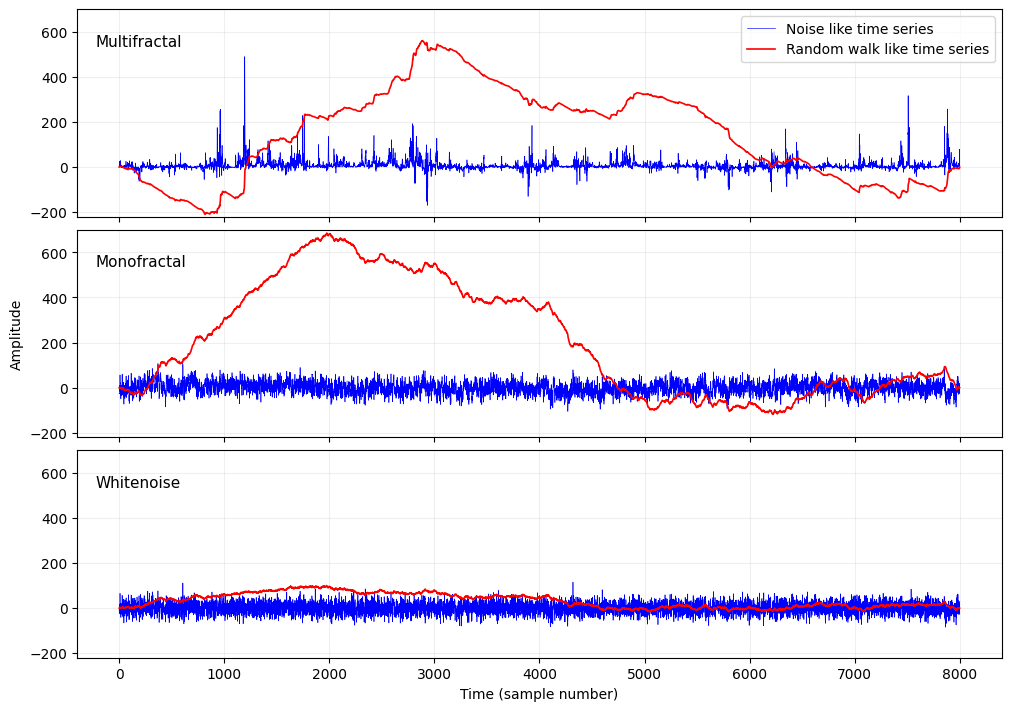

In [6]:
rw = {name: np.cumsum(x - np.mean(x)) for name, x in signals.items()}

# Figure 1
noise_plot_gain = 25
panel_order = ("multifractal", "monofractal", "whitenoise")
fig, axes = plt.subplots(
    3, 1, figsize=(10, 7), sharex=True, sharey=True, layout="constrained"
)
for ax, name in zip(axes, panel_order):
    ax.plot(
        signals[name] * noise_plot_gain,
        color="blue",
        lw=0.45,
        label=f"Noise like time series",
    )
    ax.plot(rw[name], color="red", lw=1.2, label="Random walk like time series")
    ax.text(
        0.02, 0.88, name.capitalize(), transform=ax.transAxes, va="top", fontsize=11
    )
    ax.set_ylim(-220, 700)
axes[0].legend(loc="upper right", frameon=True)
axes[1].set_ylabel("Amplitude")
axes[-1].set_xlabel("Time (sample number)")
plt.show()


whitenoise      RMS=1.000000, mean=-0.003542
monofractal     RMS=1.083341, mean=-0.039491
multifractal    RMS=1.000000, mean=0.314678


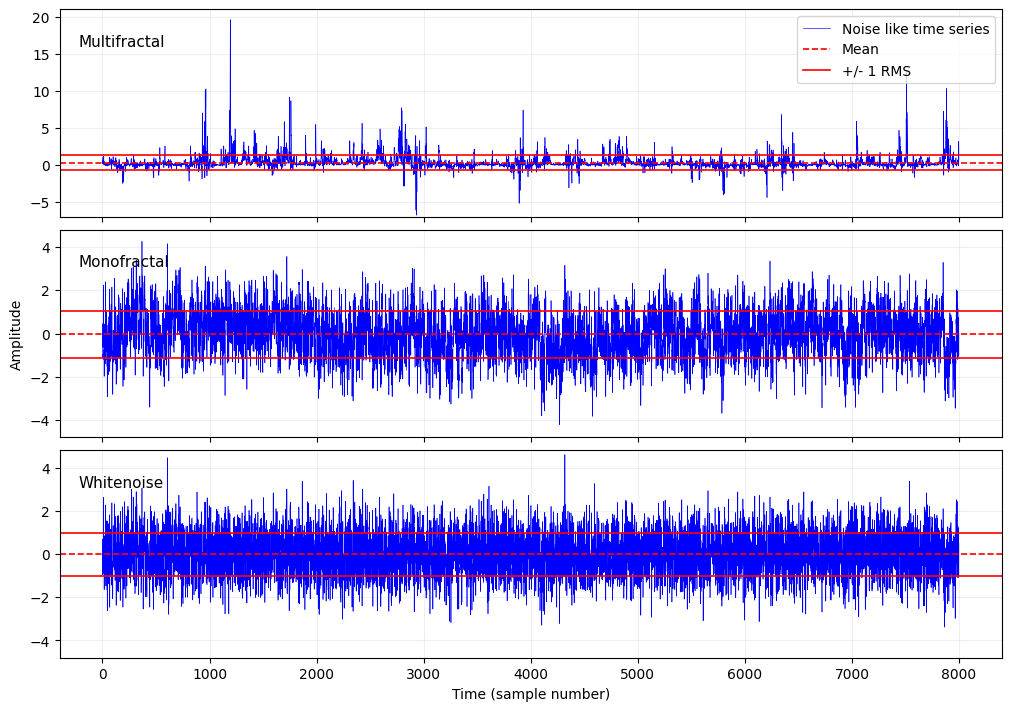

In [7]:
rms_values = {name: np.sqrt(np.mean(x**2)) for name, x in signals.items()}
for name, x in signals.items():
    print(f"{name:15s} RMS={rms_values[name]:.6f}, mean={x.mean():.6f}")

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True, layout="constrained")
for ax, name in zip(axes, ("multifractal", "monofractal", "whitenoise")):
    x = signals[name]
    mu = x.mean()
    rms = rms_values[name]
    ax.plot(x, color="blue", lw=0.45, label="Noise like time series")
    ax.axhline(mu, color="red", lw=1.2, ls="--", label="Mean")
    ax.axhline(mu + rms, color="red", lw=1.2, label="+/- 1 RMS")
    ax.axhline(mu - rms, color="red", lw=1.2)
    ax.text(
        0.02, 0.88, name.capitalize(), transform=ax.transAxes, va="top", fontsize=11
    )
    ax.set_ylim((-7, 21) if name == "multifractal" else (-4.8, 4.8))
axes[0].legend(loc="upper right")
axes[1].set_ylabel("Amplitude")
axes[-1].set_xlabel("Time (sample number)")
plt.show()


In [8]:
def local_rms(profile, scale, order=1, return_fits=False):
    n_segments = len(profile) // scale
    windows = profile[: n_segments * scale].reshape(n_segments, scale)
    t = np.linspace(-1.0, 1.0, scale)
    design = np.polynomial.polynomial.polyvander(t, order)
    basis, _ = np.linalg.qr(design)
    fits = (windows @ basis) @ basis.T
    rms = np.sqrt(np.mean((windows - fits) ** 2, axis=1))
    return (rms, fits) if return_fits else rms

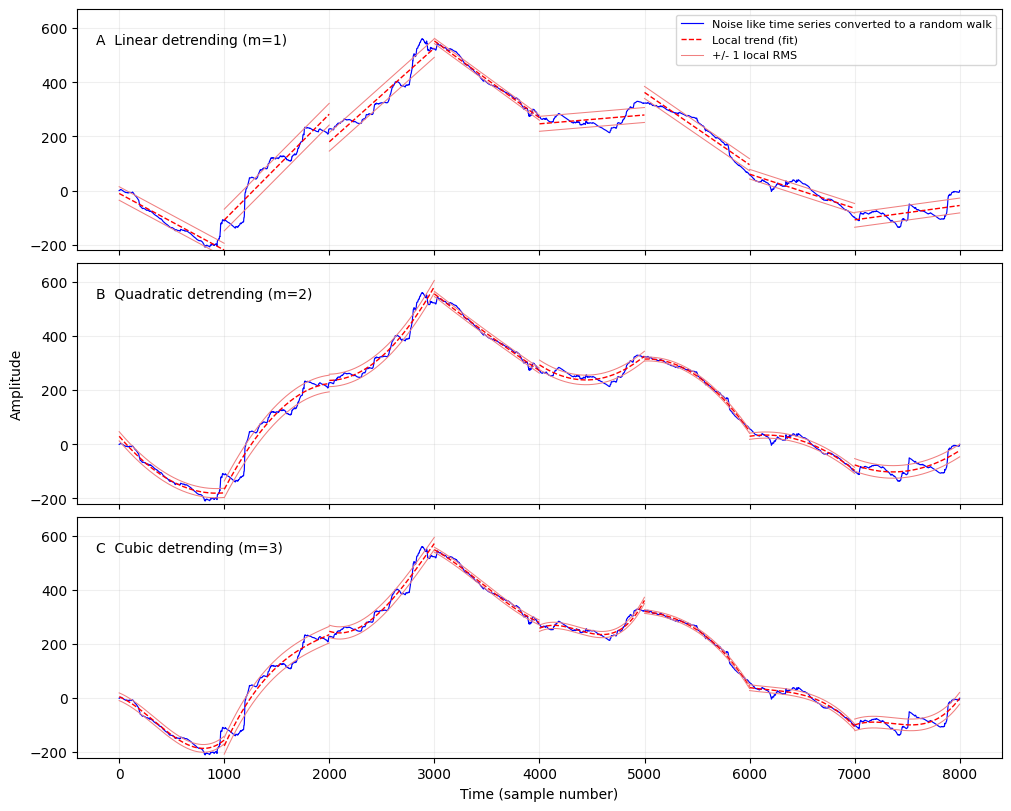

Local RMS (linear trend): [25.006 40.119 34.225  9.647 27.615 22.312 17.79  27.433]


In [9]:
scale_fig = 1000
X = rw["multifractal"]
local_rms_by_order = {
    m: local_rms(X, scale_fig, order=m, return_fits=True) for m in (1, 2, 3)
}
local, fits = local_rms_by_order[1]

fig, axes = plt.subplots(
    3, 1, figsize=(10, 8), sharex=True, sharey=True, layout="constrained"
)
for ax, (panel, order_name, m) in zip(
    axes, [("A", "Linear", 1), ("B", "Quadratic", 2), ("C", "Cubic", 3)]
):
    segment_rms, segment_fits = local_rms_by_order[m]
    ax.plot(
        X,
        color="blue",
        lw=0.85,
        label="Noise like time series converted to a random walk",
    )
    for v, trend in enumerate(segment_fits):
        t = np.arange(v * scale_fig, (v + 1) * scale_fig)
        ax.plot(
            t,
            trend,
            color="red",
            ls="--",
            lw=1,
            label="Local trend (fit)" if v == 0 else None,
        )
        for sign in (-1, 1):
            ax.plot(
                t,
                trend + sign * segment_rms[v],
                color="lightcoral",
                lw=0.75,
                label="+/- 1 local RMS" if v == 0 and sign == 1 else None,
            )
    ax.text(
        0.02,
        0.9,
        f"{panel}  {order_name} detrending (m={m})",
        transform=ax.transAxes,
        va="top",
        fontsize=10,
    )
    ax.set_ylim(-220, 670)
axes[0].legend(loc="upper right", fontsize=8)
axes[1].set_ylabel("Amplitude")
axes[-1].set_xlabel("Time (sample number)")
plt.show()
print("Local RMS (linear trend):", np.round(local, 3))


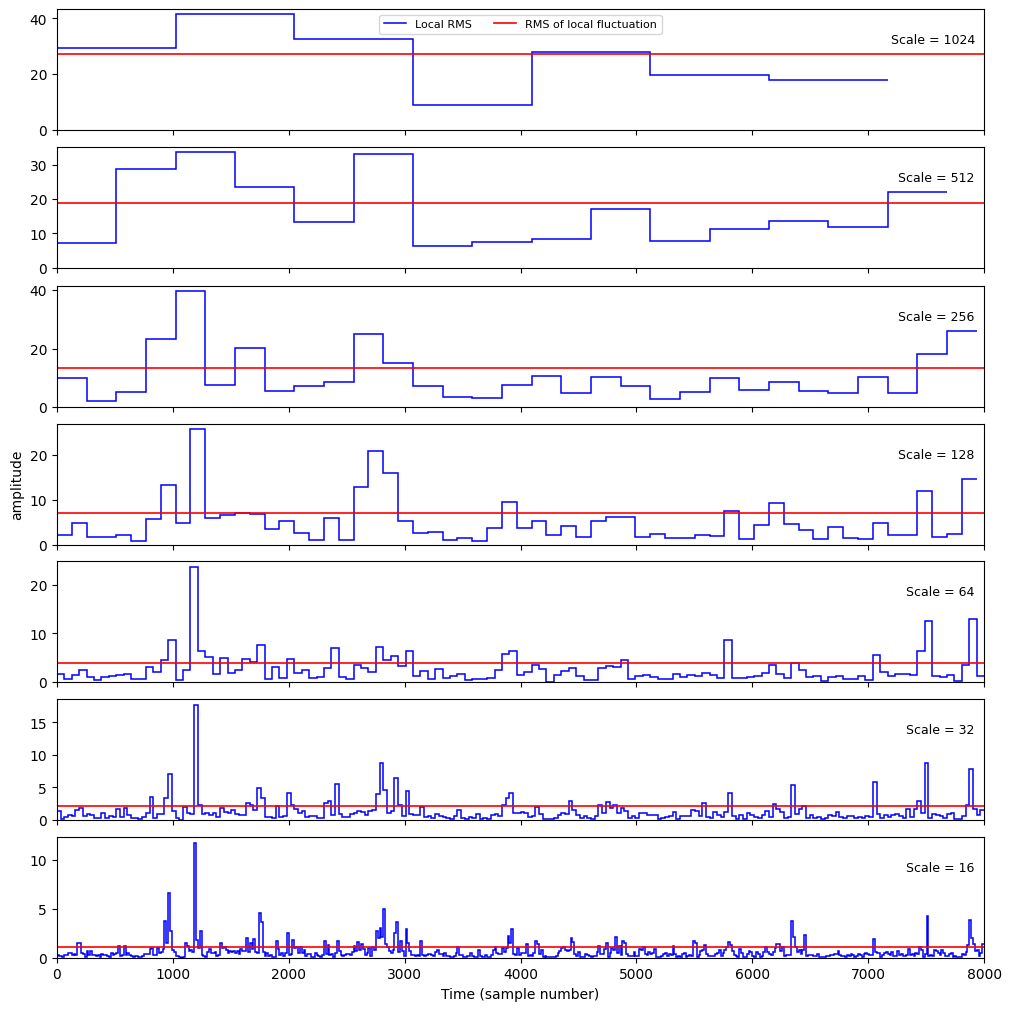

In [18]:
scales = np.array([16, 32, 64, 128, 256, 512, 1024])
order = 1
rms_by_scale = {
    name: [local_rms(X, int(s), order) for s in scales] for name, X in rw.items()
}
F = {
    name: np.array([np.sqrt(np.mean(r**2)) for r in rows])
    for name, rows in rms_by_scale.items()
}
name = "multifractal"
fig, axes = plt.subplots(
    len(scales), 1, figsize=(10, 10), sharex=True, layout="constrained"
)
for ax, j in zip(axes, range(len(scales) - 1, -1, -1)):
    s = int(scales[j])
    local_values = rms_by_scale[name][j]
    edges = np.arange(len(local_values) + 1) * s
    ax.stairs(
        local_values,
        edges,
        baseline=None,
        color="blue",
        lw=1.1,
        label="Local RMS" if j == len(scales) - 1 else None,
    )
    ax.axhline(
        F[name][j],
        color="red",
        lw=1.2,
        label="RMS of local fluctuation" if j == len(scales) - 1 else None,
    )
    ax.text(
        0.99,
        0.8,
        f"Scale = {s}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
    )
    ax.set_ylim(bottom=0)
    ax.grid(False)
axes[0].legend(loc="upper center", fontsize=8, ncol=2)
axes[3].set_ylabel("amplitude")
axes[-1].set_xlabel("Time (sample number)")
axes[-1].set_xlim(0, len(signals[name]))
plt.show()


whitenoise      seven-scale DFA H = 0.4459
monofractal     seven-scale DFA H = 0.7103
multifractal    seven-scale DFA H = 0.7791


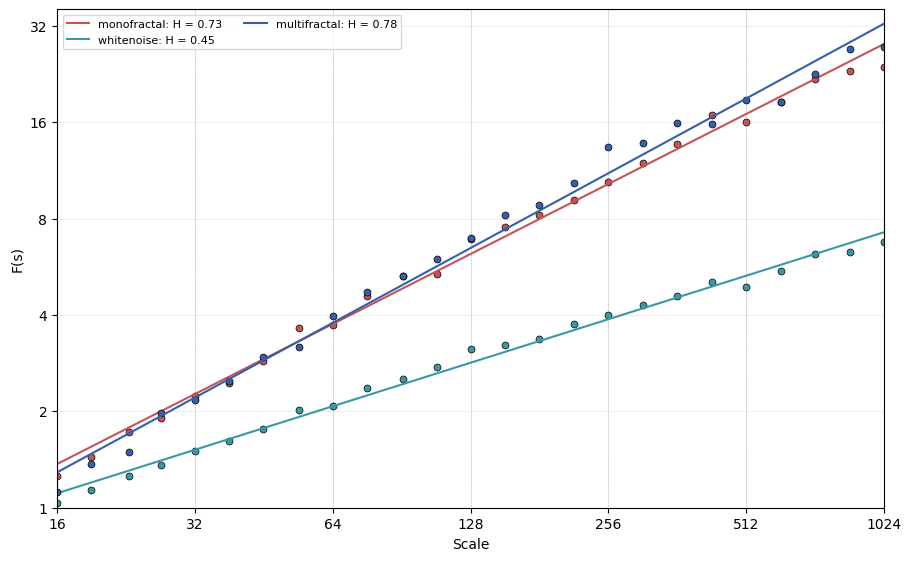

whitenoise      H = 0.4514
monofractal     H = 0.7264
multifractal    H = 0.7758


In [19]:
dfa_exponents = {}
for name, f in F.items():
    slope, intercept = np.polyfit(np.log2(scales), np.log2(f), 1)
    dfa_exponents[name] = slope
    print(f"{name:15s} seven-scale DFA H = {slope:.4f}")

scales_fig5 = np.unique(np.rint(2 ** np.arange(4, 10.001, 0.25)).astype(int))
F_fig5 = {
    name: np.array(
        [np.sqrt(np.mean(local_rms(profile, int(s), order) ** 2)) for s in scales_fig5]
    )
    for name, profile in rw.items()
}
fig5_coeff = {
    name: np.polyfit(np.log2(scales_fig5), np.log2(f), 1) for name, f in F_fig5.items()
}

fig, ax = plt.subplots(figsize=(9, 5.5), layout="constrained")
for guide in scales:
    ax.axvline(guide, color="black", ls=":", lw=0.7, alpha=0.22)
for name in ("monofractal", "whitenoise", "multifractal"):
    color = COLORS[name]
    f = F_fig5[name]
    coeff = fig5_coeff[name]
    fitted = 2 ** np.polyval(coeff, np.log2(scales_fig5))
    ax.plot(
        scales_fig5,
        f,
        "o",
        ms=5,
        color=color,
        mec="black",
        mew=0.5,
    )
    ax.plot(
        scales_fig5,
        fitted,
        "-",
        lw=1.5,
        color=color,
        label=f"{name}: H = {coeff[0]:.2f}",
    )
ax.set_xscale("log", base=2)
ax.set_yscale("log", base=2)
ax.set_xticks(scales)
ax.set_xticklabels([str(v) for v in scales])
ax.set_yticks([1, 2, 4, 8, 16, 32])
ax.set_yticklabels(["1", "2", "4", "8", "16", "32"])
ax.set(
    xlim=(16, 1024),
    ylim=(1, 36),
    xlabel="Scale",
    ylabel="F(s)",
)
ax.legend(ncol=2, fontsize=8)
plt.show()
for name in COLORS:
    print(f"{name:15s} H = {fig5_coeff[name][0]:.4f}")


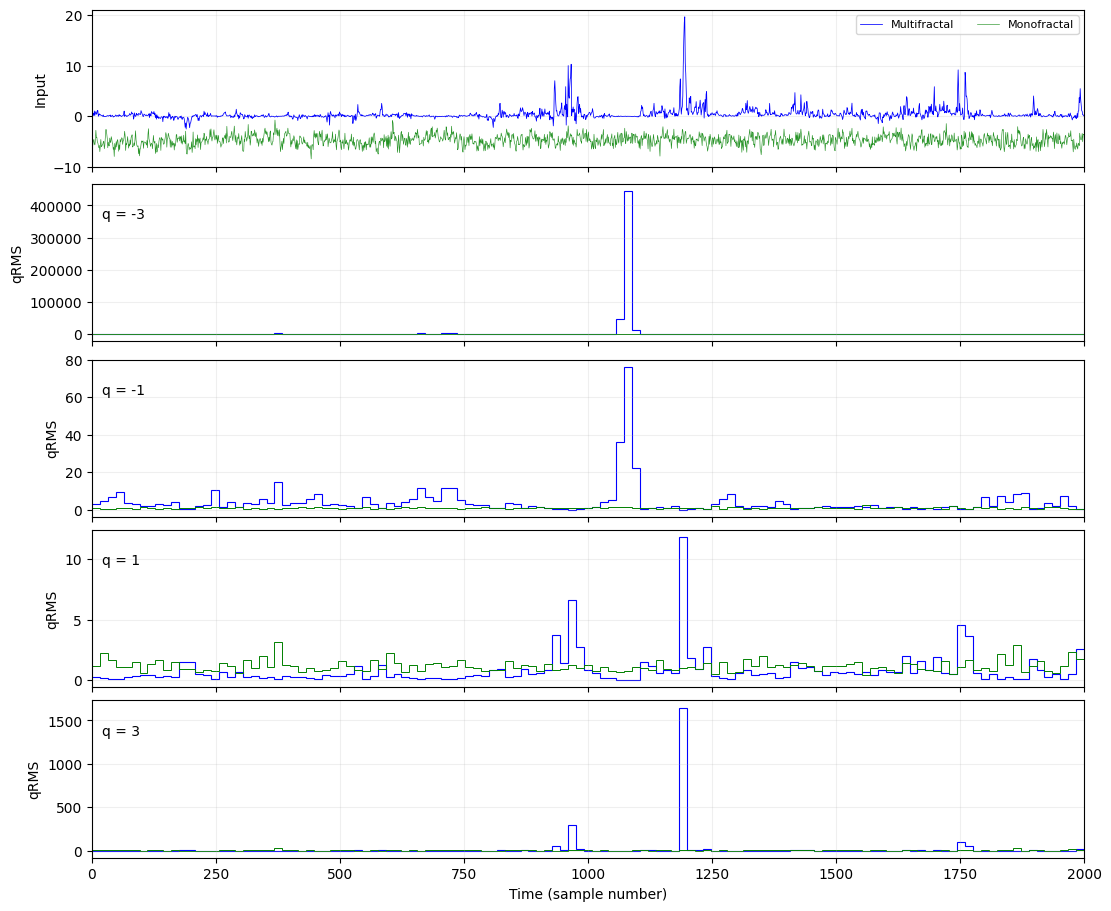

In [20]:
r7_multi = rms_by_scale["multifractal"][0]
r7_mono = rms_by_scale["monofractal"][0]
window7 = 2000
fig, axes = plt.subplots(5, 1, figsize=(11, 9), sharex=True, layout="constrained")
axes[0].plot(
    signals["multifractal"][:window7], color="blue", lw=0.55, label="Multifractal"
)
mono_display_offset = -5.0
axes[0].plot(
    signals["monofractal"][:window7] + mono_display_offset,
    color="green",
    lw=0.45,
    alpha=0.85,
    label="Monofractal",
)
axes[0].set_ylim(-10, 21)
axes[0].set_ylabel("Input")
axes[0].legend(fontsize=8, ncol=2)
for ax, qi in zip(axes[1:], [-3, -1, 1, 3]):
    edges7 = np.arange(window7 // 16 + 1) * 16
    ax.stairs(
        r7_multi[: window7 // 16] ** qi, edges7, baseline=None, color="blue", lw=0.8
    )
    ax.stairs(
        r7_mono[: window7 // 16] ** qi, edges7, baseline=None, color="green", lw=0.7
    )
    ax.set_ylabel(f"qRMS")
    ax.text(0.01, 0.85, f"q = {qi}", transform=ax.transAxes, va="top")
axes[-1].set(xlabel="Time (sample number)", xlim=(0, window7))
plt.show()


In [21]:
def q_fluctuation(rms, q_values):
    if np.any(rms <= 0):
        raise ValueError("Zero local RMS: negative q and log are undefined")
    log_rms = np.log(rms)
    return np.array(
        [
            np.exp(
                np.mean(log_rms)
                if qi == 0
                else (logsumexp(qi * log_rms) - np.log(len(rms))) / qi
            )
            for qi in q_values
        ]
    )

In [22]:
q = np.array([-3.0, -1.0, 1.0, 3.0])

Fq = {
    name: np.column_stack([q_fluctuation(r, q) for r in rows])
    for name, rows in rms_by_scale.items()
}
coefficients = {
    name: np.polyfit(np.log2(scales), np.log2(values).T, 1)
    for name, values in Fq.items()
}
Hq = {name: coeff[0] for name, coeff in coefficients.items()}
tau = {name: q * h - 1 for name, h in Hq.items()}

alpha = {name: np.diff(t) / np.diff(q) for name, t in tau.items()}
f_alpha = {name: q[:-1] * alpha[name] - tau[name][:-1] for name in COLORS}


local_scales = np.array([7, 9, 11, 13, 15, 17])
common_half = local_scales[-1] // 2
time = np.arange(common_half, len(X) - common_half)


def moving_rms(profile, size, time, order=1):
    half = size // 2
    windows = sliding_window_view(profile, size)[time - half]
    t = np.linspace(-1, 1, size)
    basis, _ = np.linalg.qr(np.polynomial.polynomial.polyvander(t, order))
    fit = (windows @ basis) @ basis.T
    return np.sqrt(np.mean((windows - fit) ** 2, axis=1))


RMS_t = {
    name: np.vstack([moving_rms(X, int(s), time, order) for s in local_scales])
    for name, X in rw.items()
}

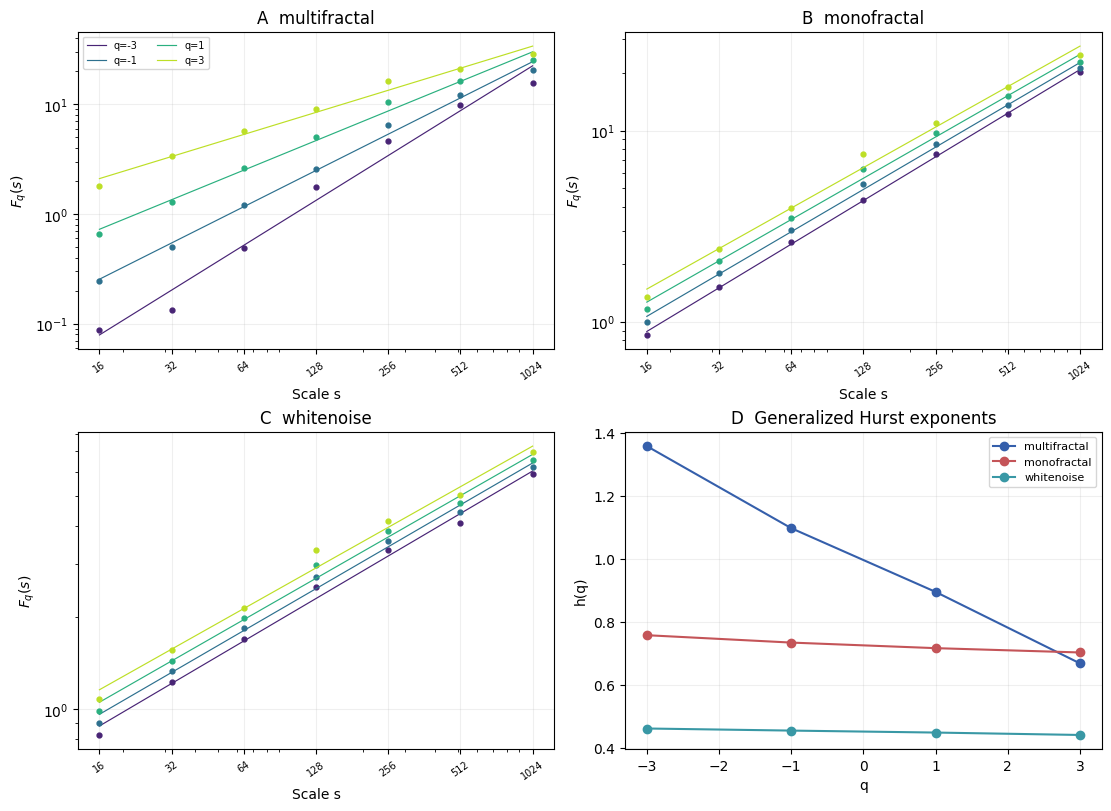

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), layout="constrained")
q_colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(q)))
for ax, name, letter in zip(
    axes.flat[:3], ("multifractal", "monofractal", "whitenoise"), "ABC"
):
    for qi in (-3.0, -1.0, 1.0, 3.0):
        i = int(np.where(q == qi)[0][0])
        color = q_colors[i]
        fit8 = 2 ** np.polyval(coefficients[name][:, i], np.log2(scales))
        ax.loglog(scales, Fq[name][i], "o", ms=3.5, color=color)
        ax.loglog(scales, fit8, "-", lw=0.85, color=color, label=f"q={qi:g}")
    ax.set(xlabel="Scale s", ylabel="$F_q(s)$", title=f"{letter}  {name}")
    ax.set_xticks(scales)
    ax.set_xticklabels([str(v) for v in scales], rotation=35, fontsize=7)
axes[0, 0].legend(ncol=2, fontsize=7)
ax = axes[1, 1]
for name in ("multifractal", "monofractal", "whitenoise"):
    ax.plot(q, Hq[name], "o-", label=name, color=COLORS[name])
ax.set(xlabel="q", ylabel="h(q)", title="D  Generalized Hurst exponents")
ax.legend(fontsize=8)
plt.show()


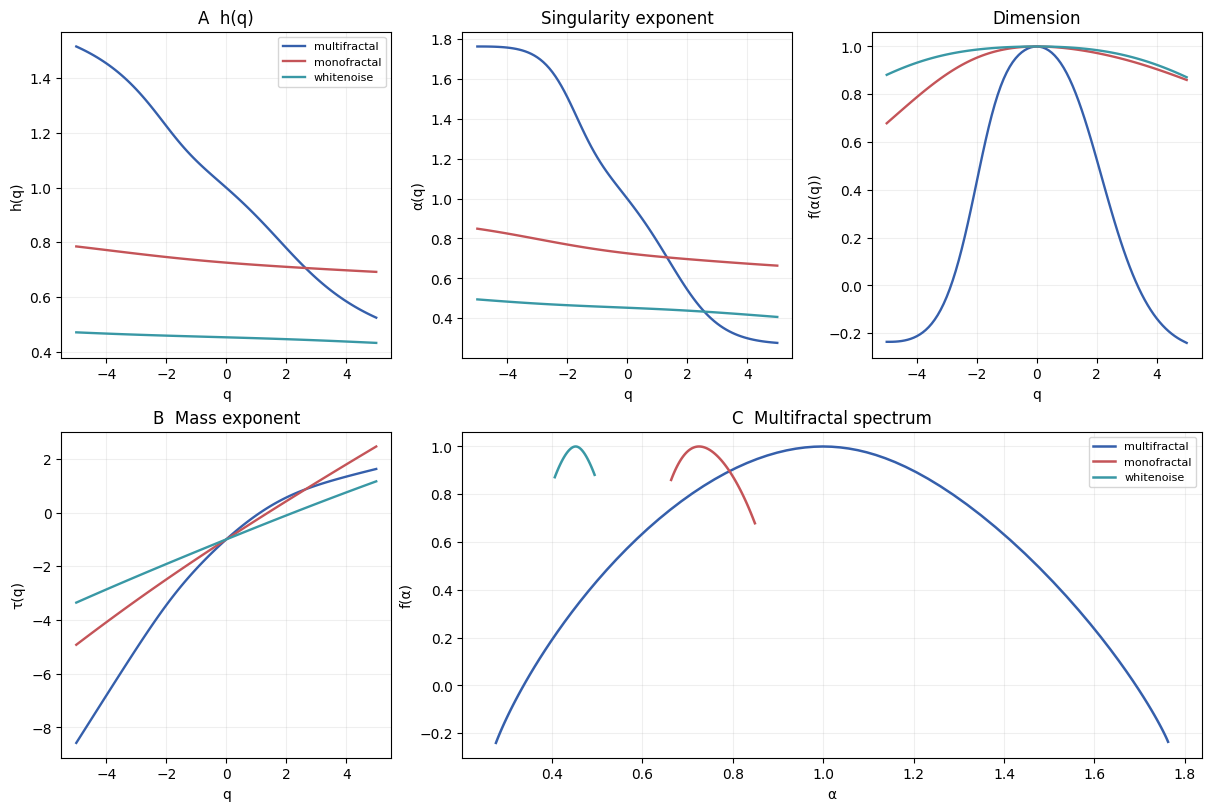

whitenoise      alpha range: 0.407–0.495; width=0.088
monofractal     alpha range: 0.664–0.849; width=0.185
multifractal    alpha range: 0.276–1.763; width=1.487


In [24]:
# Recalculate the q moments
q_fig9 = np.linspace(-5.0, 5.0, 101)
Fq_fig9 = {
    name: np.column_stack([q_fluctuation(r, q_fig9) for r in rows])
    for name, rows in rms_by_scale.items()
}
h_fig9 = {
    name: np.polyfit(np.log2(scales), np.log2(values).T, 1)[0]
    for name, values in Fq_fig9.items()
}
tau_fig9 = {name: q_fig9 * h_fig9[name] - 1 for name in COLORS}
alpha_fig9 = {
    name: np.gradient(tau_fig9[name], q_fig9, edge_order=2) for name in COLORS
}
f_fig9 = {name: q_fig9 * alpha_fig9[name] - tau_fig9[name] for name in COLORS}

fig = plt.figure(figsize=(12, 8), layout="constrained")
gs9 = fig.add_gridspec(2, 3)
ax_h = fig.add_subplot(gs9[0, 0])
ax_tau = fig.add_subplot(gs9[1, 0])
ax_alpha = fig.add_subplot(gs9[0, 1])
ax_dim = fig.add_subplot(gs9[0, 2])
ax_spectrum = fig.add_subplot(gs9[1, 1:])
for name in ("multifractal", "monofractal", "whitenoise"):
    color = COLORS[name]
    ax_h.plot(q_fig9, h_fig9[name], "-", color=color, lw=1.7, label=name)
    ax_tau.plot(q_fig9, tau_fig9[name], "-", color=color, lw=1.7)
    ax_alpha.plot(q_fig9, alpha_fig9[name], "-", color=color, lw=1.7)
    ax_dim.plot(q_fig9, f_fig9[name], "-", color=color, lw=1.7)
    ax_spectrum.plot(
        alpha_fig9[name], f_fig9[name], "-", color=color, lw=1.8, label=name
    )
ax_h.set(title="A  h(q)", xlabel="q", ylabel="h(q)")
ax_h.legend(fontsize=8)
ax_tau.set(title="B  Mass exponent", xlabel="q", ylabel="τ(q)")
ax_alpha.set(title="Singularity exponent", xlabel="q", ylabel="α(q)")
ax_dim.set(title="Dimension", xlabel="q", ylabel="f(α(q))")
ax_spectrum.set(title="C  Multifractal spectrum", xlabel="α", ylabel="f(α)")
ax_spectrum.legend(fontsize=8)
plt.show()
for name in COLORS:
    print(
        f"{name:15s} alpha range: "
        f"{alpha_fig9[name].min():.3f}–{alpha_fig9[name].max():.3f}; "
        f"width={np.ptp(alpha_fig9[name]):.3f}"
    )


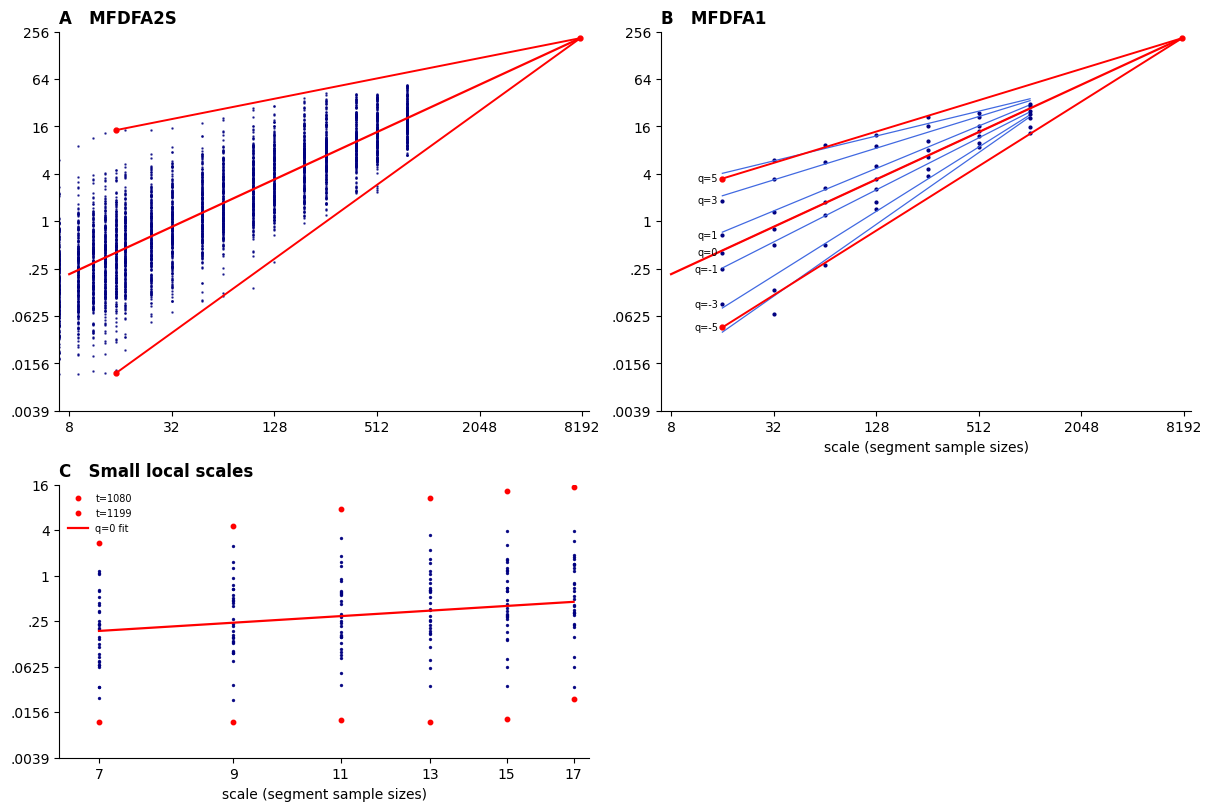

In [25]:
name12 = "multifractal"
q12 = np.array([-5.0, -3.0, -1.0, 0.0, 1.0, 3.0, 5.0])
Fq12 = np.column_stack([q_fluctuation(r, q12) for r in rms_by_scale[name12]])
coeff12 = np.polyfit(np.log2(scales), np.log2(Fq12).T, 1)
coef0_12 = coeff12[:, np.flatnonzero(q12 == 0)[0]]
n12 = len(signals[name12])
endpoint12 = 2 ** np.polyval(coef0_12, np.log2(n12))
line_x12 = np.geomspace(8, n12, 220)
baseline12 = 2 ** np.polyval(coef0_12, np.log2(line_x12))

fig = plt.figure(figsize=(12, 8), layout="constrained")
gs12 = fig.add_gridspec(2, 2, height_ratios=[1, 0.72])
ax_a = fig.add_subplot(gs12[0, 0])
ax_b = fig.add_subplot(gs12[0, 1])
ax_c = fig.add_subplot(gs12[1, 0])
ax_unused = fig.add_subplot(gs12[1, 1])
ax_unused.axis("off")

scales_a12 = np.array(
    [7, 9, 11, 13, 15, 17, 24, 32, 48, 64, 96, 128, 192, 256, 384, 512, 768]
)
centers_a12 = np.linspace(384, n12 - 385, 250, dtype=int)
for s in scales_a12:
    rms_a12 = moving_rms(rw[name12], int(s), centers_a12)
    ax_a.plot(
        np.full(len(rms_a12), s),
        rms_a12,
        ".",
        color="navy",
        ms=1.6,
        alpha=0.72,
        rasterized=True,
    )
ax_a.plot(line_x12, baseline12, color="red", lw=1.6)
s15 = 15
lo12, hi12 = np.min(RMS_t[name12][-2]), np.max(RMS_t[name12][-2])
for value in (lo12, hi12):
    ax_a.plot([s15, n12], [value, endpoint12], color="red", lw=1.4)
    ax_a.plot(s15, value, "o", color="red", ms=3.5)
ax_a.plot(n12, endpoint12, "o", color="red", ms=3.5)

for i, qi in enumerate(q12):
    fit12 = 2 ** np.polyval(coeff12[:, i], np.log2(scales))
    ax_b.plot(scales, Fq12[i], ".", color="navy", ms=4)
    ax_b.plot(scales, fit12, "-", color="royalblue", lw=0.9)
    ax_b.annotate(
        f"q={qi:g}",
        (scales[0], Fq12[i, 0]),
        xytext=(-3, 0),
        textcoords="offset points",
        ha="right",
        va="center",
        fontsize=7,
    )
ax_b.plot(line_x12, baseline12, color="red", lw=1.6)
for i in (0, -1):
    ax_b.plot([scales[0], n12], [Fq12[i, 0], endpoint12], color="red", lw=1.4)
    ax_b.plot(scales[0], Fq12[i, 0], "o", color="red", ms=3.5)
ax_b.plot(n12, endpoint12, "o", color="red", ms=3.5)

indices_c12 = np.linspace(0, len(time) - 1, 30, dtype=int)
for j in indices_c12:
    ax_c.plot(local_scales, RMS_t[name12][:, j], ".", color="navy", ms=2.8, alpha=0.9)
for target in (1080, 1199):
    j = int(np.argmin(np.abs(time - target)))
    ax_c.plot(
        local_scales,
        RMS_t[name12][:, j],
        "o",
        color="red",
        ms=3.2,
        label=f"t={time[j]}",
    )
ax_c.plot(
    local_scales,
    2 ** np.polyval(coef0_12, np.log2(local_scales)),
    color="red",
    lw=1.6,
    label="q=0 fit",
)

for ax in (ax_a, ax_b, ax_c):
    ax.set_xscale("log", base=2)
    ax.set_yscale("log", base=2)
    ax.grid(False)
    ax.spines[["top", "right"]].set_visible(False)
for ax in (ax_a, ax_b):
    ax.set_xlim(7, 9000)
    ax.set_ylim(2**-8, 2**8)
    ax.set_xticks(2.0 ** np.array([3, 5, 7, 9, 11, 13]))
    ax.set_xticklabels(["8", "32", "128", "512", "2048", "8192"])
    ax.set_yticks(2.0 ** np.arange(-8, 9, 2))
    ax.set_yticklabels([".0039", ".0156", ".0625", ".25", "1", "4", "16", "64", "256"])
ax_a.set_title("A   MFDFA2S", loc="left", fontweight="bold")
ax_b.set_title("B   MFDFA1", loc="left", fontweight="bold")
ax_b.set_xlabel("scale (segment sample sizes)")
ax_c.set_xlim(6.5, 17.5)
ax_c.set_ylim(2**-8, 2**4)
ax_c.set_xticks(local_scales)
ax_c.set_xticklabels([str(v) for v in local_scales])
ax_c.set_yticks(2.0 ** np.arange(-8, 5, 2))
ax_c.set_yticklabels([".0039", ".0156", ".0625", ".25", "1", "4", "16"])
ax_c.set_title("C   Small local scales", loc="left", fontweight="bold")
ax_c.set_xlabel("scale (segment sample sizes)")
ax_c.legend(fontsize=7, frameon=False, loc="upper left")
plt.show()


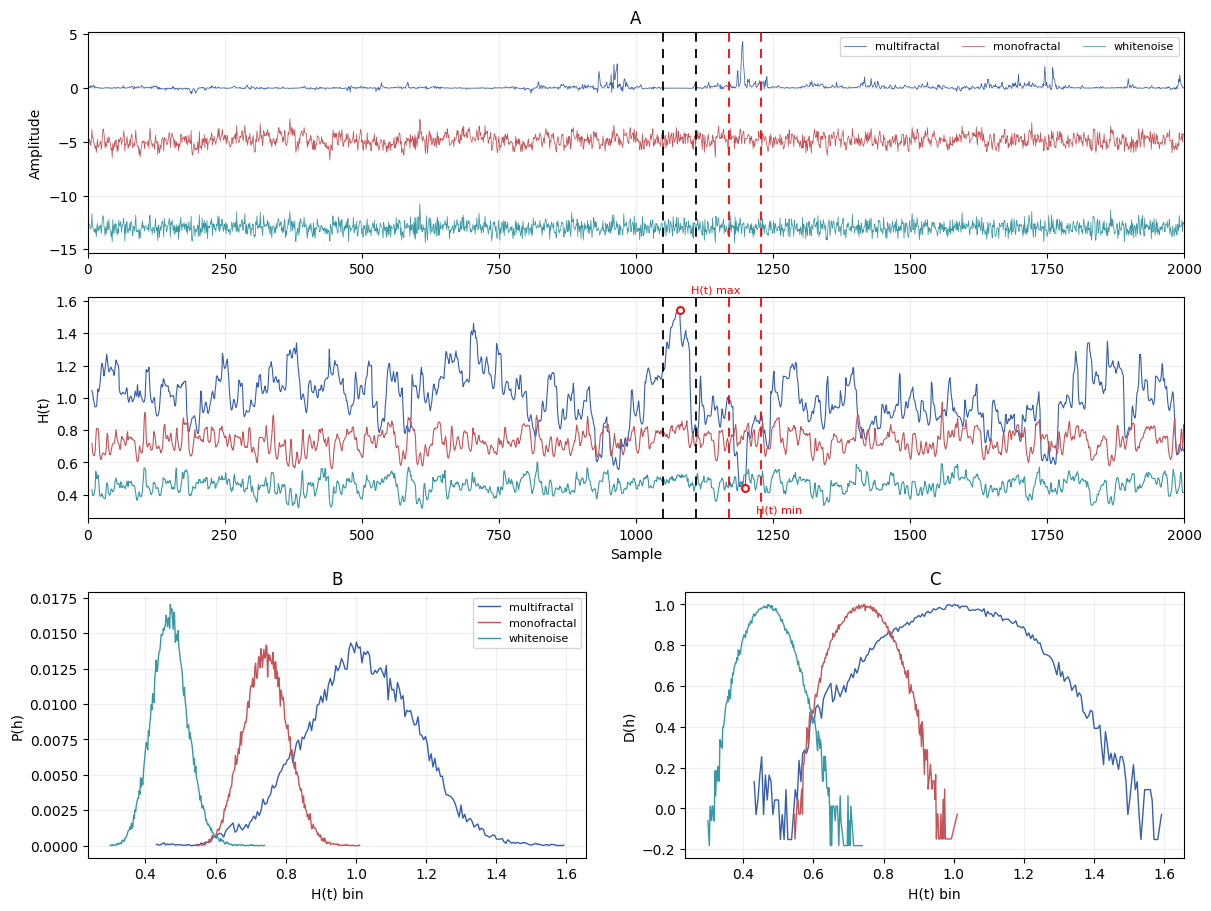

In [26]:
Ht = {}
histograms = {}
for name in ("multifractal", "monofractal", "whitenoise"):
    f0_13 = np.array([q_fluctuation(r, np.array([0.0]))[0] for r in rms_by_scale[name]])
    coef0_13 = np.polyfit(np.log2(scales), np.log2(f0_13), 1)
    h0_13 = coef0_13[0]
    baseline_log2_13 = np.polyval(coef0_13, np.log2(local_scales))
    Ht[name] = h0_13 + (baseline_log2_13[:, None] - np.log2(RMS_t[name])) / np.log2(
        len(signals[name]) / local_scales[:, None]
    )
    ht_flat13 = Ht[name].ravel()
    counts13, edges13 = np.histogram(ht_flat13, bins=round(np.sqrt(len(ht_flat13))))
    centers13 = (edges13[:-1] + edges13[1:]) / 2
    ph13 = counts13 / counts13.sum()
    dh13 = np.full(len(ph13), np.nan)
    nonzero13 = counts13 > 0
    dh13[nonzero13] = 1 - np.log(ph13[nonzero13] / ph13.max()) / (
        -np.log(np.mean(scales))
    )
    histograms[name] = (centers13, ph13, dh13)

fig = plt.figure(figsize=(12, 9), layout="constrained")
gs13 = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1.2])
ax_signal = fig.add_subplot(gs13[0, :])
ax_ht = fig.add_subplot(gs13[1, :], sharex=ax_signal)
ax_ph = fig.add_subplot(gs13[2, 0])
ax_dh = fig.add_subplot(gs13[2, 1])
first13 = 2000
for name, offset, display_factor in (
    ("multifractal", 0, 0.22),
    ("monofractal", -5, 0.5),
    ("whitenoise", -13, 0.5),
):
    ax_signal.plot(
        np.arange(first13),
        offset + display_factor * signals[name][:first13],
        lw=0.55,
        color=COLORS[name],
        label=name,
    )
    visible = time < first13
    ax_ht.plot(
        time[visible], Ht[name][-2, visible], lw=0.8, color=COLORS[name], label=name
    )
for center, color in ((1080, "black"), (1199, "red")):
    for boundary in (center - 30, center + 30):
        for ax in (ax_signal, ax_ht):
            ax.axvline(boundary, color=color, ls=(0, (5, 4)), lw=1.3, zorder=4)
for center, label, color, shift in (
    (1080, "H(t) max", "red", (8, 12)),
    (1199, "H(t) min", "red", (8, -18)),
):
    j = int(np.argmin(np.abs(time - center)))
    y = Ht["multifractal"][-2, j]
    ax_ht.plot(time[j], y, "o", ms=5, mfc="white", mec=color, mew=1.4, zorder=6)
    ax_ht.annotate(
        label,
        (time[j], y),
        xytext=shift,
        textcoords="offset points",
        fontsize=8,
        color=color,
    )
ax_signal.set(ylabel="Amplitude", title="A")
ax_signal.legend(fontsize=8, ncol=3)
ax_ht.set(xlabel="Sample", ylabel="H(t)", xlim=(0, first13))
for name in ("multifractal", "monofractal", "whitenoise"):
    center, ph, dh = histograms[name]
    mask = np.isfinite(dh)
    ax_ph.plot(center, ph, color=COLORS[name], lw=1, label=name)
    ax_dh.plot(center[mask], dh[mask], color=COLORS[name], lw=1, label=name)
ax_ph.set(title="B", xlabel="H(t) bin", ylabel="P(h)")
ax_dh.set(title="C", xlabel="H(t) bin", ylabel="D(h)")
ax_ph.legend(fontsize=8)
plt.show()
